In [1]:
import re
import pandas as pd
import glob
import os

# Función que permite procesar el log asociado a un experimento y devuelve 3 elementos: 
# el resumen del rendimiento y tiempos en cada dataset, las estadisticas globales y el accuracy por clase.
def procesar_log_detallado(ruta_archivo):

    # Abrimos el archivo en modo lectura
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            texto = f.read()
    except FileNotFoundError:
        return f"Error: No se encontró el archivo {ruta_archivo}", None, None

    # Separamos el log por secciones asociadas a cada dataset
    secciones = re.split(r"\*{20,}Ejecutando prueba sobre el dataset", texto)
    
    resumen_data = []
    clases_data = []
    
    # Recorremos las secciones del log asociadas a cada dataset
    for seccion in secciones[1:]:
        # 1. Obtenemos el nombre del dataset
        lineas = seccion.strip().split('\n')
        dataset_name = lineas[0].split('*')[0].strip()
        
        # 2. Extraemos el OA y AA finales obtenidos sobre el dataset
        oa_match = re.search(r"OA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        aa_match = re.search(r"AA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        
        # 2.5 Extraemos las medidas de tiempo
        tiempo_total_match = re.search(r"Tiempo entrenamiento total medio .*?:\s*([\d.]+)\s*s", seccion)
        tiempo_epoca_match = re.search(r"Tiempo medio por época .*?:\s*([\d.]+)\s*s", seccion)
        
        # Si se han encontrado el OA y el AA se añaden al resumen de resultados
        if oa_match and aa_match:
            datos_dataset = {
                "Dataset": dataset_name,
                "OA (%)": float(oa_match.group(1)),
                "std OA (%)": float(oa_match.group(2)),
                "AA (%)": float(aa_match.group(1)),
                "std AA (%)": float(aa_match.group(2))
            }
            
            # Añadimos los tiempos si los encuentra (por si algún log antiguo no los tiene)
            if tiempo_total_match:
                datos_dataset["Tiempo Total (s)"] = float(tiempo_total_match.group(1))
            else:
                datos_dataset["Tiempo Total (s)"] = None
                
            if tiempo_epoca_match:
                datos_dataset["Tiempo por Época (s)"] = float(tiempo_epoca_match.group(1))
            else:
                datos_dataset["Tiempo por Época (s)"] = None

            resumen_data.append(datos_dataset)
            
        # 3. Extraemos el accuracy obtenido para cada clase
        bloque_clases = re.search(r"ACCURACY POR CLASE:(.*?)---", seccion, re.DOTALL)
        if bloque_clases:
            # Obtenemos los resultados para cada clase (ignorando la desviación típica de la clase)
            matches_clase = re.findall(r"Clase (\d+):\s*([\d.]+)%", bloque_clases.group(1))
            # Almacenamos el accuracy asociado a cada una de las clases
            for num_clase, valor_acc in matches_clase:
                clases_data.append({
                    "Dataset": dataset_name,
                    "Clase": f"Clase {num_clase}",
                    "Accuracy (%)": float(valor_acc)
                })
    
    # Si no se han encontrado datos válidos se devuelve un mensaje de error.
    if not resumen_data:
        return "No se encontraron datos válidos.", None, None

    # Convertimos las listas en dataframes
    df_resumen = pd.DataFrame(resumen_data)
    df_clases_long = pd.DataFrame(clases_data)
    
    # Transformamos la tabla de clases a formato ancho
    df_clases_wide = df_clases_long.pivot(index='Dataset', columns='Clase', values='Accuracy (%)')
    
    # Calculamos las estadísticas globales
    stats = {
        "Métrica": ["OA Global", "AA Global", "Tiempo Total (s)", "Tiempo por Época (s)"],
        "Media (%)": [df_resumen["OA (%)"].mean(), df_resumen["AA (%)"].mean(),df_resumen["Tiempo Total (s)"].mean(),df_resumen["Tiempo por Época (s)"].mean()],
        "Desviación (%)": [df_resumen["OA (%)"].std(), df_resumen["AA (%)"].std(), df_resumen["Tiempo Total (s)"].std(),df_resumen["Tiempo por Época (s)"].std()]
    }
    
    # Pasamos las estadísticas a un dataframe
    df_stats = pd.DataFrame(stats)
    
    return df_resumen, df_stats, df_clases_wide

In [2]:
def imprimirResultados(ruta_carpeta):
    #Obtenemos los ficheros que terminan en .log
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))

    datos_comparacion = []

    if not archivos:
        print(f"No se encontraron archivos .log en la carpeta '{ruta_carpeta}'.")
    else:
        #Recorremos cada uno de los archivos asociados a las distintas ejecuciones
        for archivo in archivos:
            #Obtenemos el nombre asociado a la prueba
            nombre_prueba = os.path.basename(archivo)
            
            print(f"\n{'='*30} ARCHIVO: {nombre_prueba} {'='*30}")

            nombre_prueba = os.path.basename(archivo).replace(".log", "").replace("resultados_", "")
            
            #Procesamos el log asociado a la prueba
            df_res, df_st, df_clases = procesar_log_detallado(archivo)
            
            #Si se leyeron correctamente los datos pasamos a imprimirlos por pantalla y a almacenarlos en datos_comparacion para poder graficar los resultados
            if isinstance(df_res, pd.DataFrame):
                print("\n************* TABLA RESUMEN (OA/AA): *************")
                print(df_res.to_string(index=False))
                
                print("\n************* ACCURACY POR CLASE POR DATASET: *************")
                print(df_clases.fillna("-").to_string())
                
                print("\n************* ESTADÍSTICAS GLOBALES: *************")
                print(df_st.to_string(index=False))
                
                #Guardamos los datos necesarios para realizar la gráfica (medias y desviaciones)
                oa_global = df_st.loc[df_st['Métrica'] == 'OA Global', 'Media (%)'].values[0]
                aa_global = df_st.loc[df_st['Métrica'] == 'AA Global', 'Media (%)'].values[0]
                
                oa_std = df_st.loc[df_st['Métrica'] == 'OA Global', 'Desviación (%)'].values[0]
                aa_std = df_st.loc[df_st['Métrica'] == 'AA Global', 'Desviación (%)'].values[0]

                t_total_medio = df_res["Tiempo Total (s)"].mean() if "Tiempo Total (s)" in df_res.columns else None
                t_epoca_medio = df_res["Tiempo por Época (s)"].mean() if "Tiempo por Época (s)" in df_res.columns else None
                
                datos_comparacion.append({
                    "Prueba": nombre_prueba,
                    "OA Global (%)": oa_global,
                    "AA Global (%)": aa_global,
                    "OA Std (%)": oa_std,
                    "AA Std (%)": aa_std,
                    "Tiempo Total Medio (s)": t_total_medio,
                    "Tiempo Época Medio (s)": t_epoca_medio
                })
            else:
                print(df_res)

        if datos_comparacion:
            datos_ordenados = sorted(
                datos_comparacion, 
                key=lambda x: (x["AA Global (%)"], x["OA Global (%)"]), 
                reverse=True
            )
            
            
            
            # Definimos anchos fijos
            w_rank = 8
            w_metodo = 40  
            w_oa = 22
            w_aa = 22

            print(f"\n\n{'='*30} RESUMEN RESULTADOS {'='*30}")

            # Encabezado
            header = f"{'Ranking':<{w_rank}} | {'Método':<{w_metodo}} | {'OA Global (%) ± Std':<{w_oa}} | {'AA Global (%) ± Std':<{w_aa}}"
            print(header)
            print("-" * len(header))

            # Filas
            for i, dato in enumerate(datos_ordenados, start=1):
                oa_str = f"{dato['OA Global (%)']:.2f} ± {dato['OA Std (%)']:.2f}"
                aa_str = f"{dato['AA Global (%)']:.2f} ± {dato['AA Std (%)']:.2f}"
                
                # Usamos las mismas variables de ancho (w_rank, w_metodo, etc.)
                print(f"#{i:<{w_rank-1}} | {dato['Prueba']:<{w_metodo}} | {oa_str:<{w_oa}} | {aa_str:<{w_aa}}")

            print("=" * len(header))
    
        return datos_comparacion

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def graficaComparacionModelos(datos_comparacion):
    if datos_comparacion:
        # Creamos una copia para proteger el DataFrame original
        df_comparacion = pd.DataFrame(datos_comparacion).copy()

        if 'AA Global (%)' in df_comparacion.columns:
            df_comparacion = df_comparacion.sort_values(by='AA Global (%)', ascending=False)
        
        # Reemplazar guiones bajos por espacios en los nombres de las pruebas
        if 'Prueba' in df_comparacion.columns:
            df_comparacion['Prueba'] = df_comparacion['Prueba'].str.replace('_', ' ')
        
        # Comprobamos si los tiempos se han extraído correctamente y no son todos nulos
        tiene_tiempos = "Tiempo Total Medio (s)" in df_comparacion.columns and not df_comparacion["Tiempo Total Medio (s)"].isnull().all()
        
        num_graficas = 3 if tiene_tiempos else 2
        # Ajustamos el tamaño a 13x6.5 por cada subgráfica para que los textos quepan bien
        fig, axes = plt.subplots(num_graficas, 1, figsize=(13, 6.5 * num_graficas))
        
        # Asignamos los ejes base
        ax1 = axes[0]
        ax2 = axes[1]

        # ---------------------------------------------------------
        # 1. Gráfica de Precisión
        # ---------------------------------------------------------
        df_comparacion.set_index('Prueba')[['OA Global (%)', 'AA Global (%)']].plot(
            kind='bar', ax=ax1, color=['#1f77b4', '#ff7f0e'], alpha=0.8, width=0.75
        )
        ax1.set_title('Media Precisión Global (OA y AA)', fontsize=14, fontweight='bold', pad=15)
        ax1.set_ylabel('Precisión (%)', fontsize=11)
        ax1.set_ylim(80, 103) # Margen extra arriba para que queden cómodas las etiquetas
        
        ax1.set_axisbelow(True)
        ax1.grid(axis='y', linestyle='--', alpha=0.5)
        ax1.legend(["OA Global", "AA Global"], loc='upper right')
        
        # AGREGAR VALORES ENCIMA DE LAS BARRAS
        for container in ax1.containers:
            ax1.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8.5, fontweight='semibold')
            
        # Configuración individual del eje X para que no se rompa el diseño
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=35, ha='right', fontsize=9.5)
        ax1.set_xlabel('') # Ocultamos el título del eje intermedio para evitar saturación

        # ---------------------------------------------------------
        # 2. Gráfica de Desviación
        # ---------------------------------------------------------
        df_comparacion.set_index('Prueba')[['OA Std (%)', 'AA Std (%)']].plot(
            kind='bar', ax=ax2, color=['#2ca02c', '#d62728'], alpha=0.8, width=0.75
        )
        ax2.set_title('Desviación estándar (OA y AA)', fontsize=14, fontweight='bold', pad=15)
        ax2.set_ylabel('Variación (%)', fontsize=11)
        
        # Ajuste dinámico del tope de la escala Std para evitar colisiones
        valores_std = df_comparacion[['OA Std (%)', 'AA Std (%)']].values
        ymax_std = valores_std[valores_std > 0].max() * 1.15 if valores_std.size else 5
        ax2.set_ylim(bottom=0, top=ymax_std)
        
        ax2.set_axisbelow(True)
        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        ax2.legend(["OA Std", "AA Std"], loc='upper right')
        
        # AGREGAR VALORES ENCIMA DE LAS BARRAS
        for container in ax2.containers:
            ax2.bar_label(container, fmt='%.2f', padding=3, fontsize=8.5, fontweight='semibold')
            
        # Configuración individual del eje X
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha='right', fontsize=9.5)
        
        if tiene_tiempos:
            ax2.set_xlabel('')
        else:
            ax2.set_xlabel('Experimentos', fontsize=11, labelpad=10)

        # ---------------------------------------------------------
        # 3. Gráfica de Tiempos (SOLO TIEMPO POR ÉPOCA)
        # ---------------------------------------------------------
        if tiene_tiempos:
            ax3 = axes[2]
            
            df_comparacion.set_index('Prueba')[['Tiempo Época Medio (s)']].plot(
                kind='bar', ax=ax3, color=['#8c564b'], alpha=0.8, width=0.4
            )
            ax3.set_title('Coste Computacional (Tiempo Medio por Época)', fontsize=14, fontweight='bold', pad=15)
            ax3.set_ylabel('Tiempo (segundos)', fontsize=11)
            ax3.set_xlabel('Experimentos', fontsize=11, labelpad=10)

            # Margen dinámico superior para el coste temporal
            ax3.set_ylim(bottom=0, top=df_comparacion['Tiempo Época Medio (s)'].max() * 1.15)

            ax3.set_axisbelow(True)
            ax3.grid(axis='y', linestyle='--', alpha=0.5)
            ax3.legend(["Tiempo Medio por Época"], loc='upper right')
            
            # AGREGAR VALORES ENCIMA DE LAS BARRAS
            for container in ax3.containers:
                ax3.bar_label(container, fmt='%.1fs', padding=3, fontsize=8.5, fontweight='semibold')
                
            # Configuración individual del eje X para la gráfica final
            ax3.set_xticklabels(ax3.get_xticklabels(), rotation=35, ha='right', fontsize=9.5)

        plt.tight_layout()
        plt.show()

## Resultados usando el aumentado de la clase minoritaria en el dataloader

In [4]:
ruta_carpeta = "resultadosPruebas"

datos_aum=imprimirResultados(ruta_carpeta)


============================== ARCHIVO: resultados_CUTMIX_PyTorch.log ==============================

************* TABLA RESUMEN (OA/AA): *************
        Dataset  OA (%)  std OA (%)  AA (%)  std AA (%)  Tiempo Total (s)  Tiempo por Época (s)
        oitaven   94.33        0.16   92.85        0.47            262.99                2.6299
     das_mestas   90.52        0.16   89.28        0.29            476.11                4.7611
      eiras_dam   94.91        0.34   90.68        1.68            188.37                1.8837
  ermidas_creek   97.50        0.17   96.07        0.36            287.97                2.8797
ferreiras_river   91.01        0.12   79.40        1.17            662.08                6.6208
     mera_river   90.23        0.09   87.94        3.46            752.76                7.5276
           ulla   98.18        0.57   98.59        0.54             18.37                0.1837
          xesta   97.79        0.09   93.95        1.13            744.68     

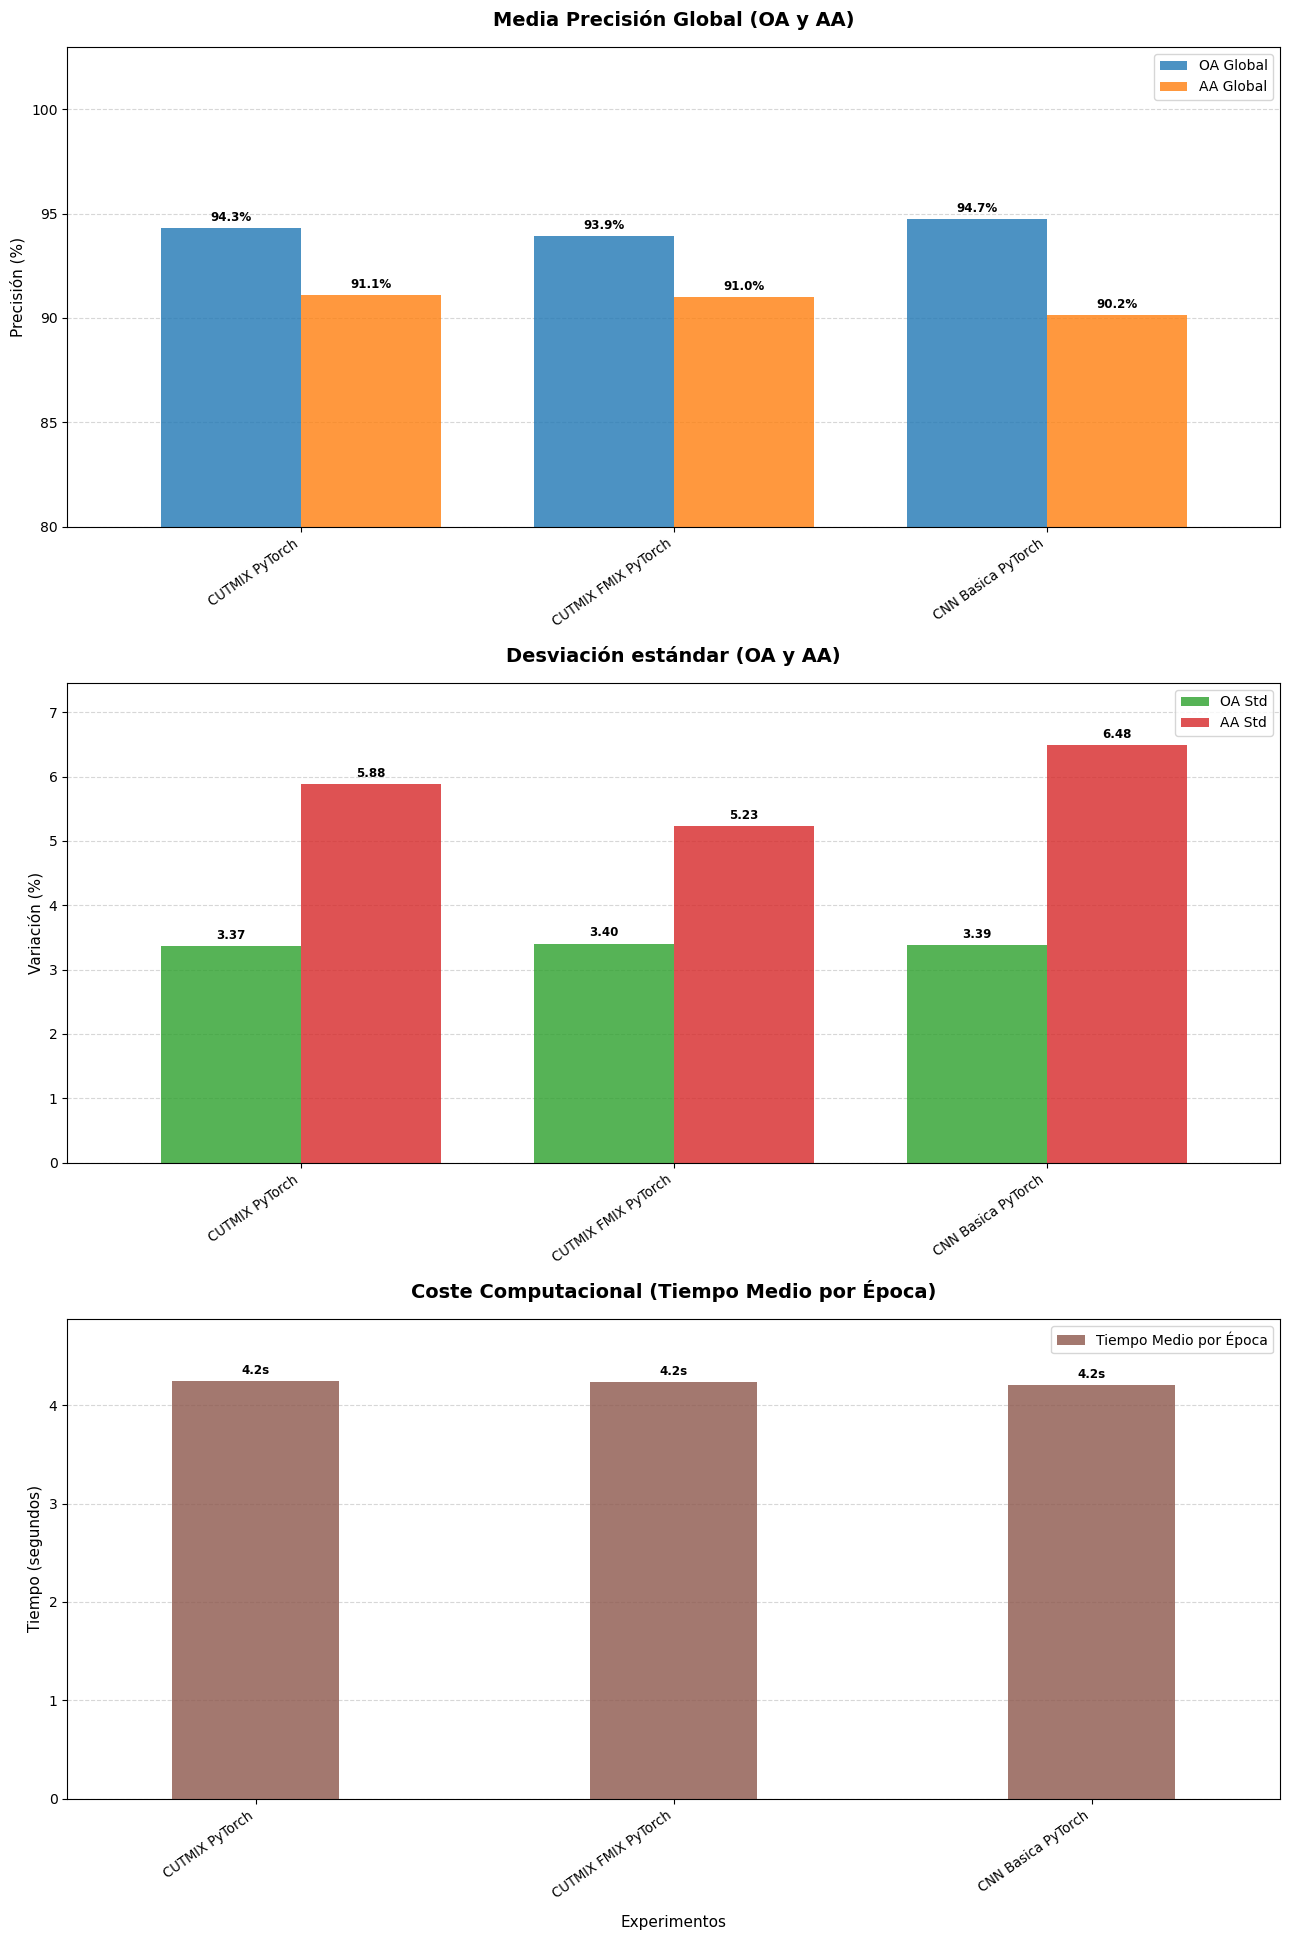

In [5]:
graficaComparacionModelos(datos_aum)

# Comportamiento de las distintas versiones por cada dataset

In [6]:
# DICCIONARIO GLOBAL DE COLORES
PALETA_COLORES = {
    # FASE 1:
    # CNN Básica
    "CNN_Basica": "#6baed6",                 
    "CNN_Basica_PyTorch": "#6baed6",
    "CNN_Basica_Aum": "#1f77b4",             
    "CNN_Basica_Aumento": "#1f77b4",
    
    #CutMix
    "CUTMIX": "#a1d99b",                     
    "CUTMIX_PyTorch": "#a1d99b",
    "CUTMIX_Aum": "#2ca02c",                 
    "CUTMIX_Aumento": "#2ca02c",
    
    #FMix
    "FMIX": "#c49c94",                       
    "FMIX_PyTorch": "#c49c94",
    "FMIX_Aum": "#8c564b",                   
    "FMIX_Aumento": "#8c564b",
    
    #MixUp
    "MIXUP": "#c7c7c7",                      
    "MIXUP_PyTorch": "#c7c7c7",
    "MIXUP_Aum": "#7f7f7f",                  
    "MIXUP_Aumento": "#7f7f7f",
    
    #CutMix + FMix
    "CUTMIX_FMIX": "#9edae5",                
    "CUTMIX_FMIX_PyTorch": "#9edae5",
    "CUTMIX_FMIX_Aum": "#17becf",            
    "CUTMIX_FMIX_Aumento": "#17becf",


    # FASES 3 y 4
    "VIT_Basica": "#e377c2",                
    "VIT_Basica_Aumentado": "#9467bd",       
    "VIT+CUTMIX": "#ff7f0e",                 
    "VIT+CUTMIX+FMIX": "#d62728",            

    # FASE 2
    "0, Flips": "#bcbd22",                   
    "1, Rotación": "#aec7e8",
    "3, Rotación_Zoom": "#ffbb78",
    "11, Rotación_Borrado Aleatorio": "#f7b6d2",
    "12, Rotación_Zoom_Borrado Aleatorio": "#dbdb8d"
}

Datasets detectados: ['das_mestas', 'eiras_dam', 'ermidas_creek', 'ferreiras_river', 'mera_river', 'oitaven', 'ulla', 'xesta']

Generando gráficas para: das_mestas...


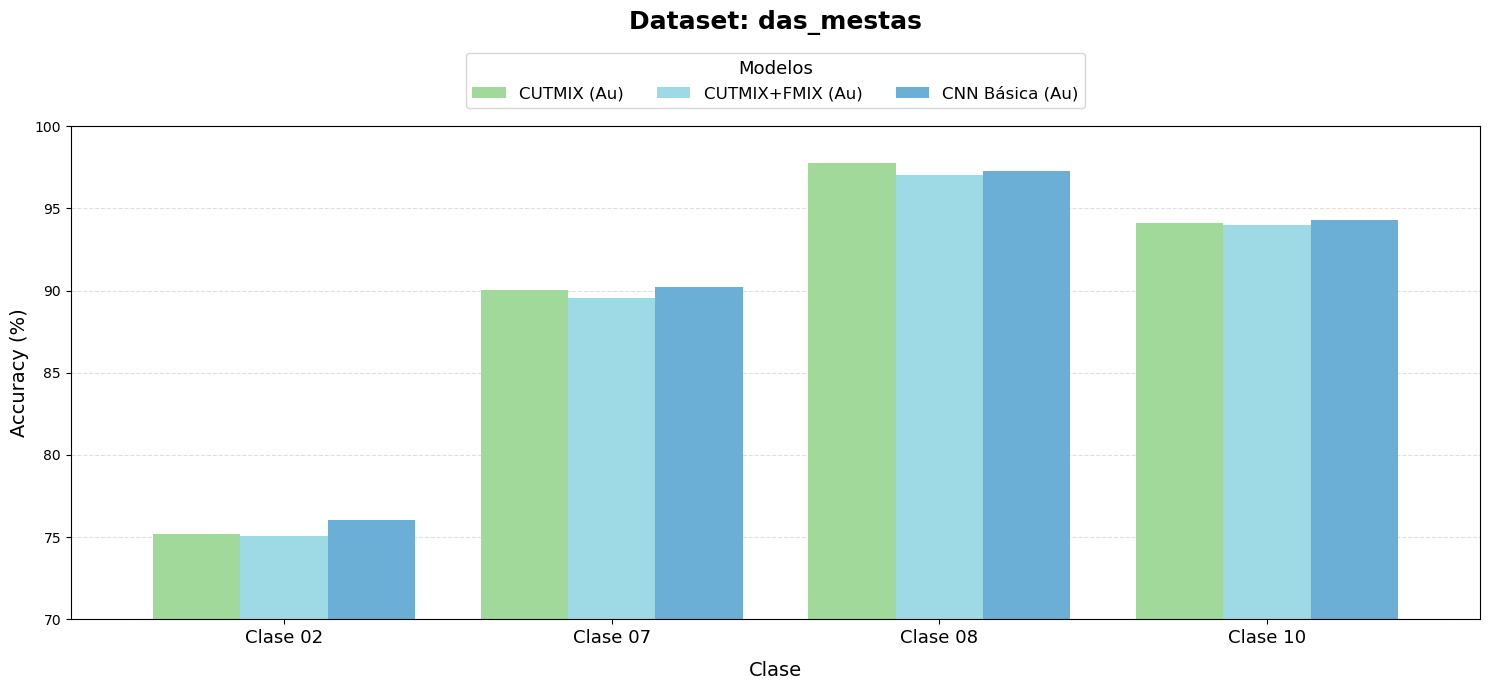


Generando gráficas para: eiras_dam...


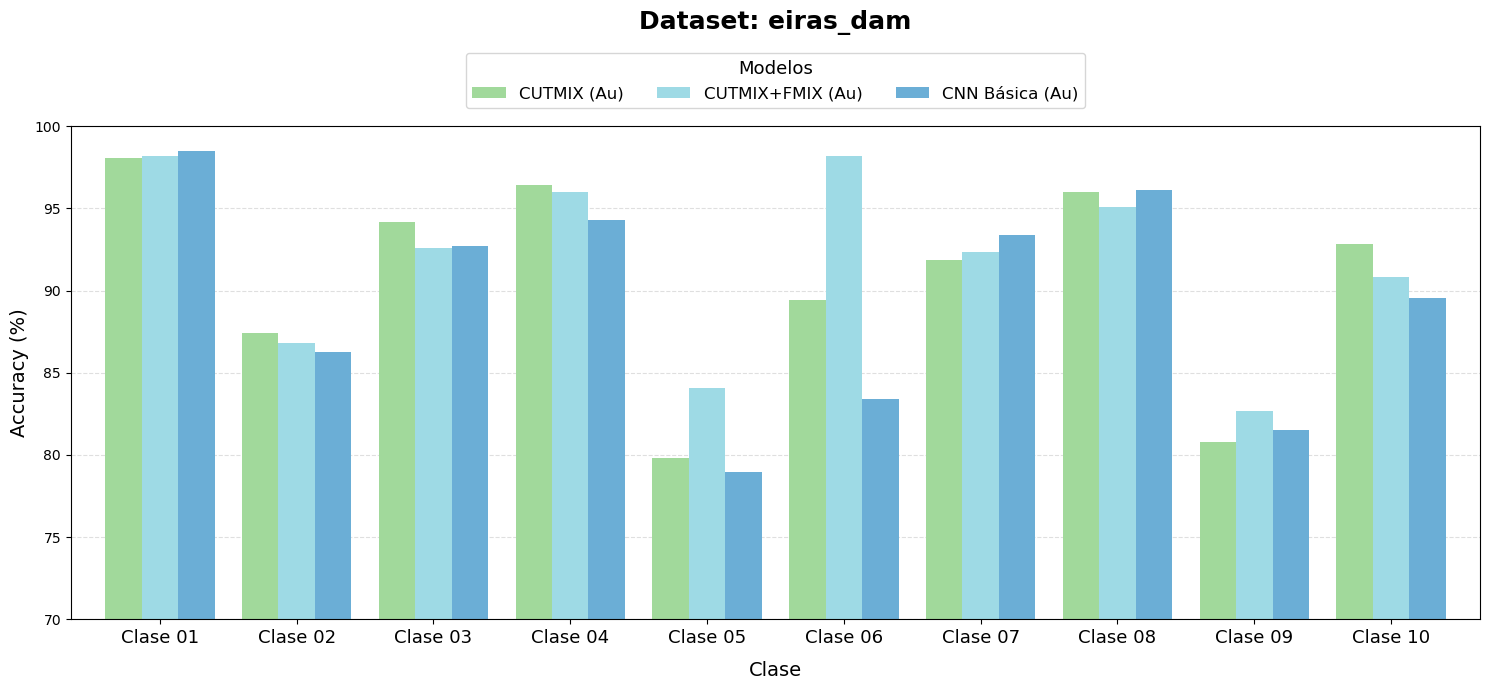


Generando gráficas para: ermidas_creek...


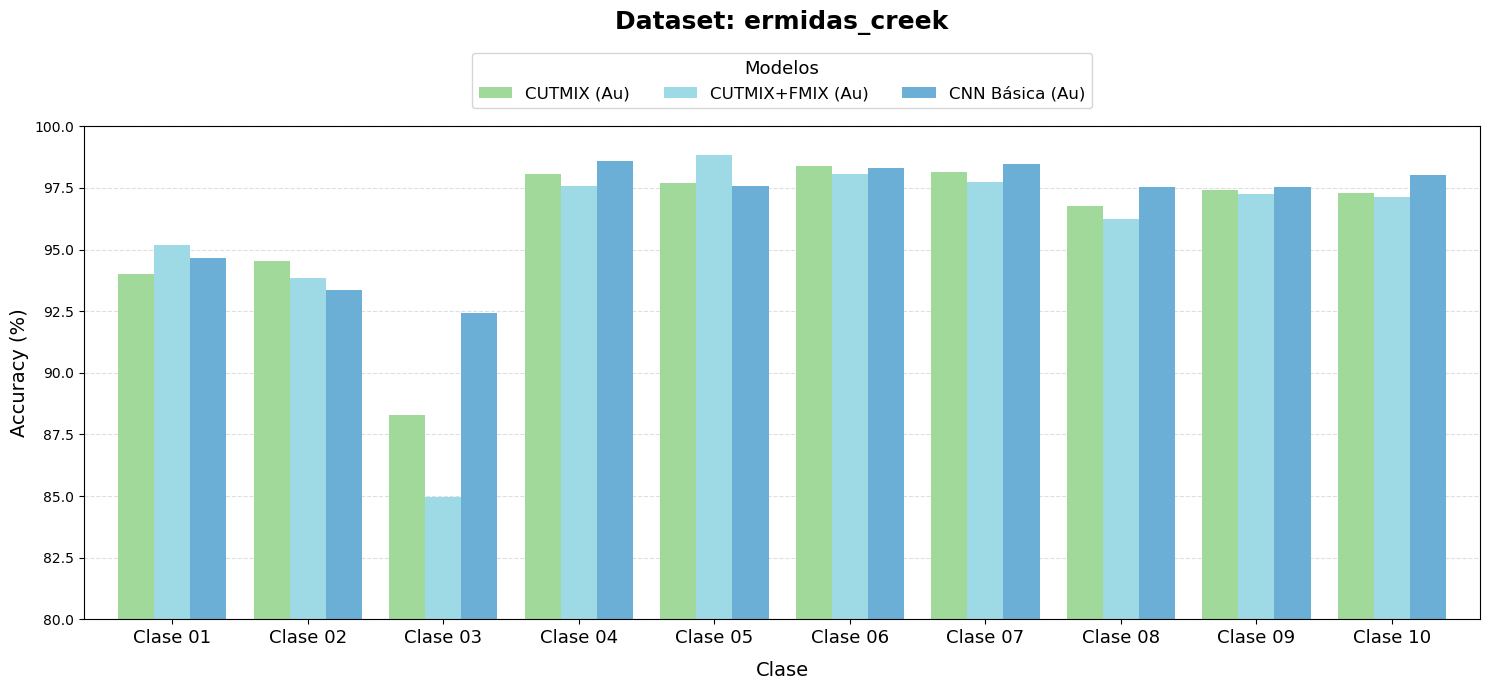


Generando gráficas para: ferreiras_river...


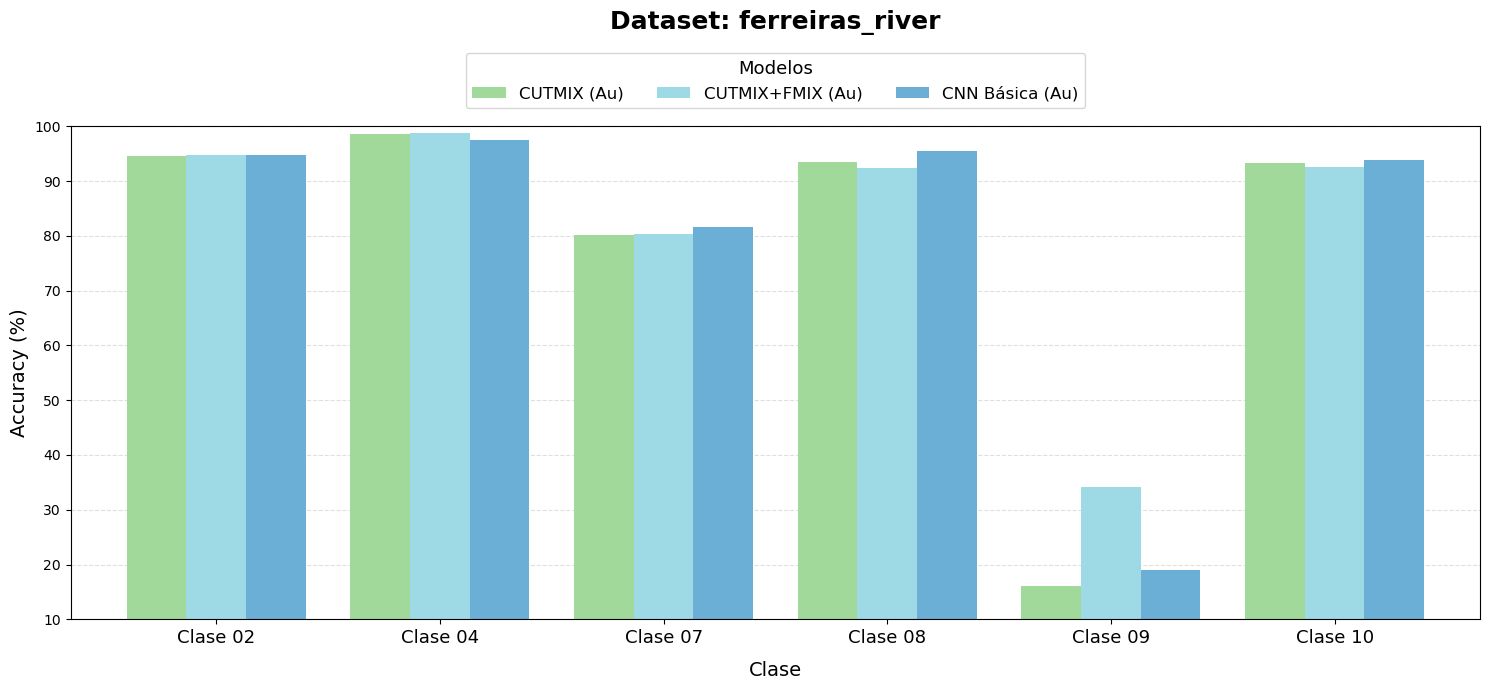


Generando gráficas para: mera_river...


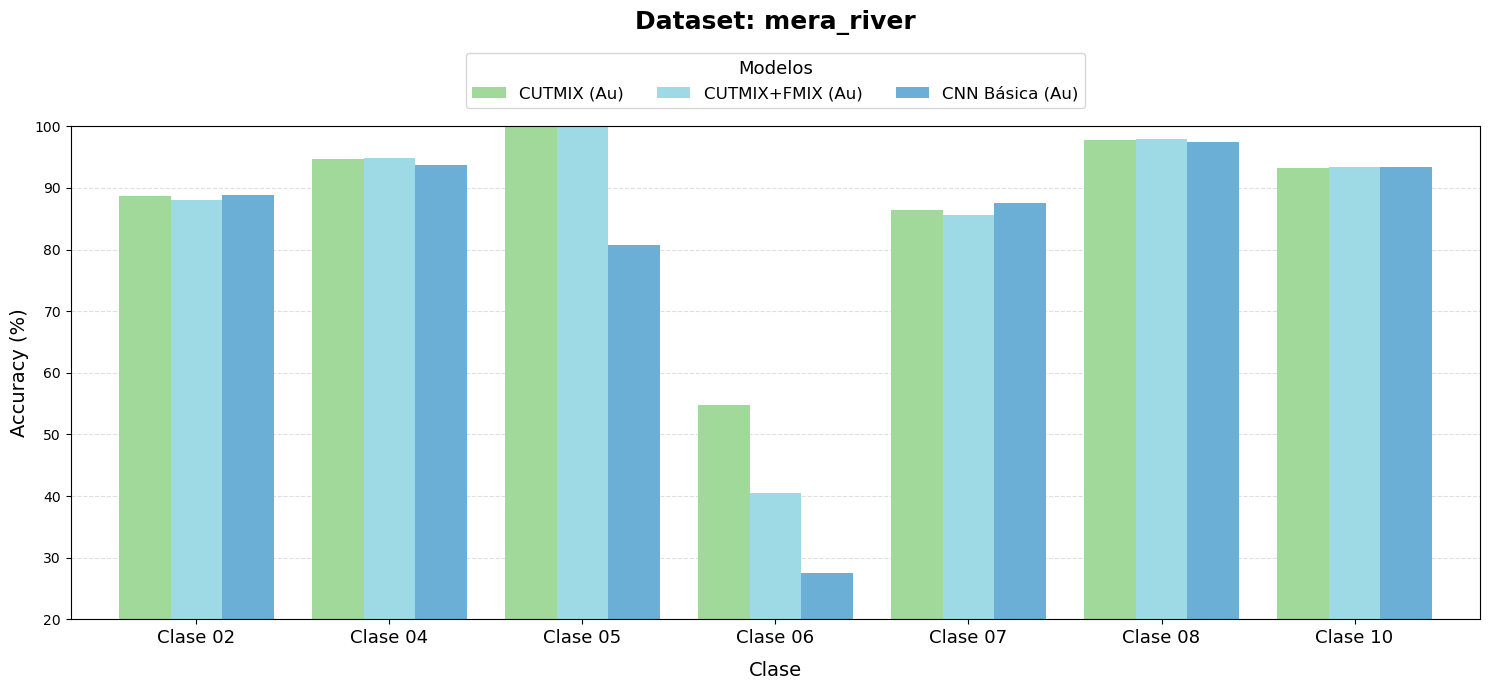


Generando gráficas para: oitaven...


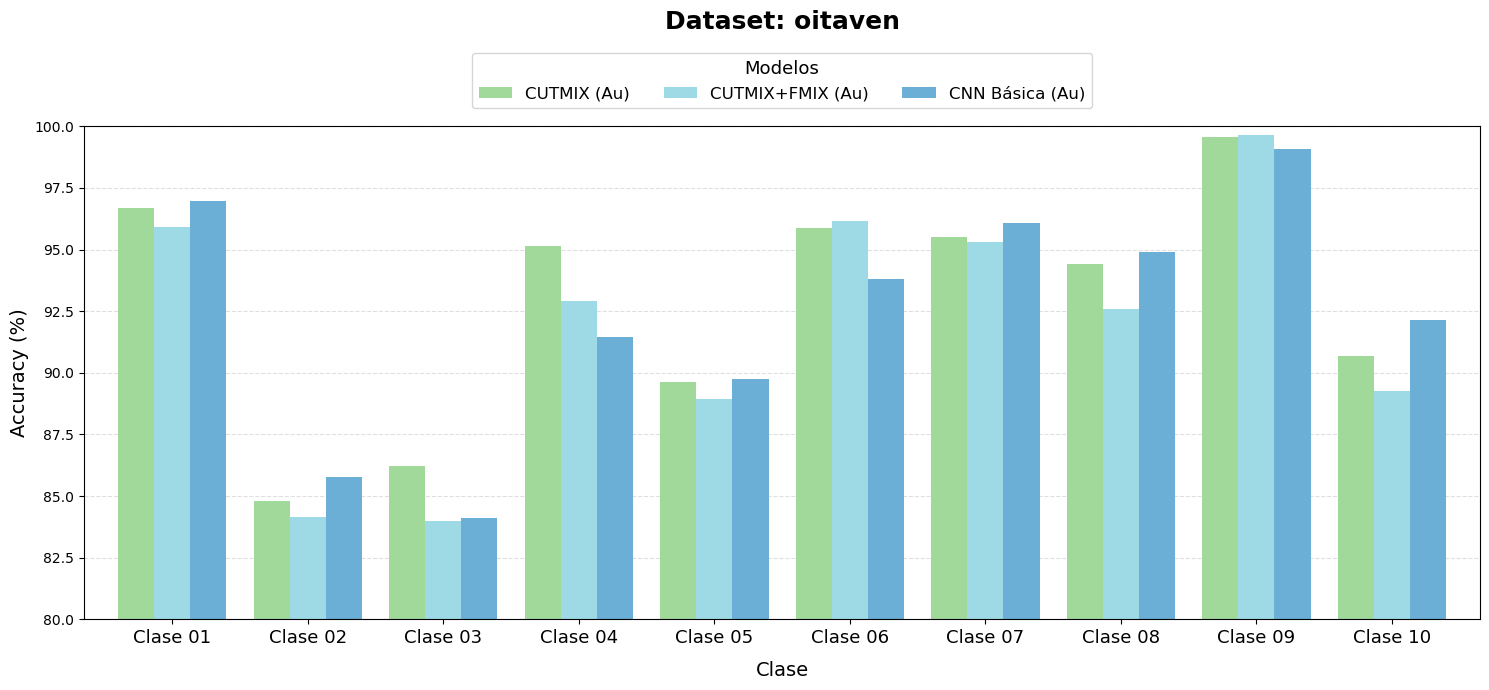


Generando gráficas para: ulla...


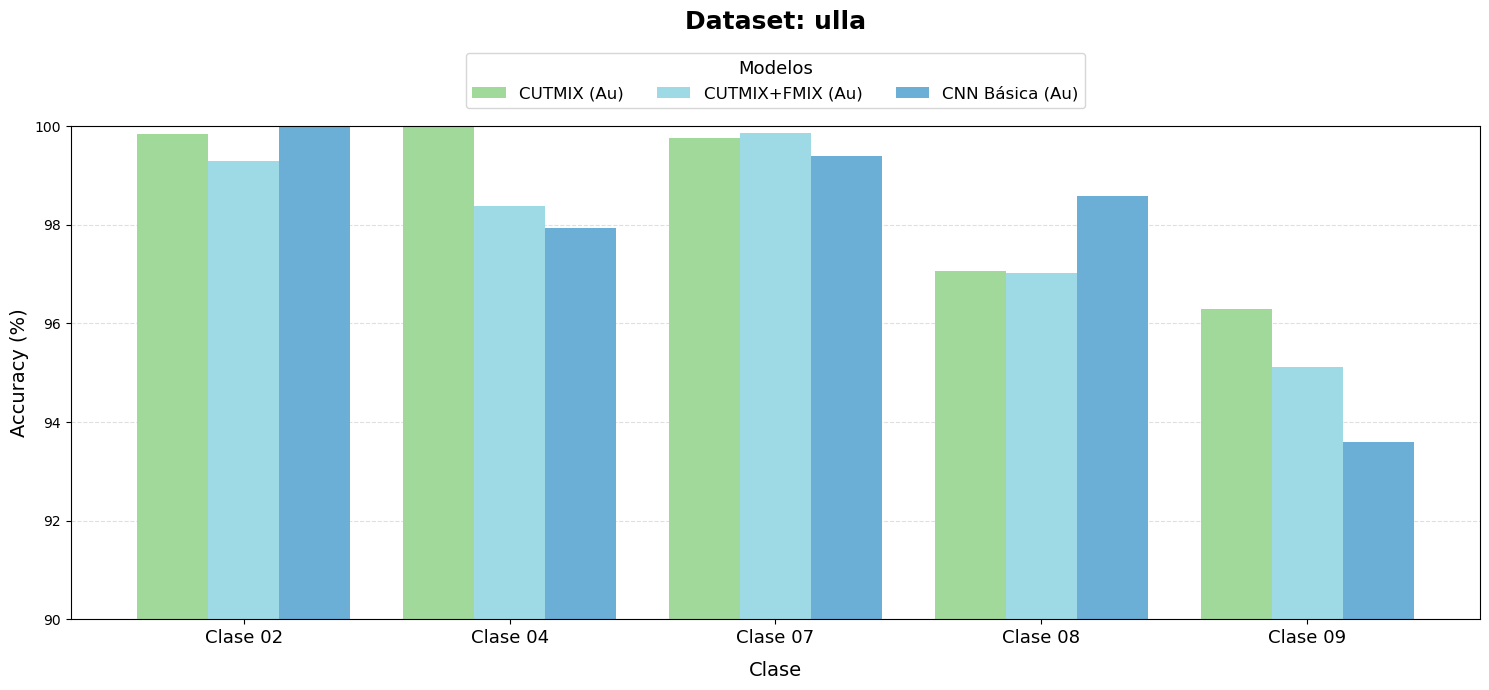


Generando gráficas para: xesta...


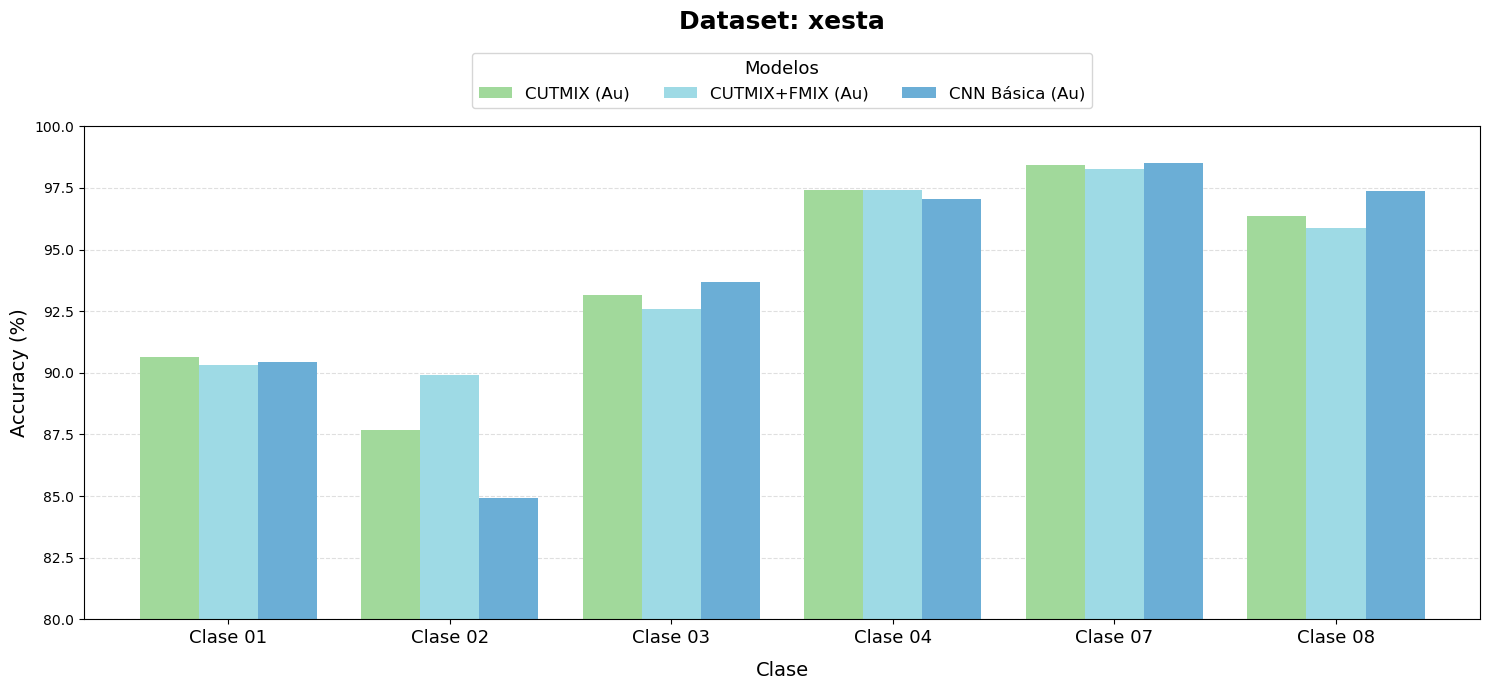

In [7]:
import glob
import math
import os
import matplotlib.pyplot as plt
import pandas as pd

# Graficar resultados por dataset
def graficar_clases_separado_limpio(dataset_objetivo):
    RUTA_CARPETA = "resultadosPruebas" 
    modelos_base = ["CNN_Basica_PyTorch", "CUTMIX_PyTorch", "CUTMIX_FMIX_PyTorch"]
    
    df_original = pd.DataFrame()
    aa_por_modelo = {} 

    # Recolección de datos
    for modelo in modelos_base:
        ruta_orig = os.path.join(RUTA_CARPETA, f"resultados_{modelo}.log")

        if os.path.exists(ruta_orig):
            _, df_stats, df_clases_orig = procesar_log_detallado(ruta_orig)
            
            if df_clases_orig is not None and dataset_objetivo in df_clases_orig.index:
                df_original[modelo] = df_clases_orig.loc[dataset_objetivo]
                
                try:
                    valor_aa = df_stats.loc[df_stats['Métrica'] == 'AA Global', 'Media (%)'].values[0]
                    aa_por_modelo[modelo] = valor_aa
                except:
                    aa_por_modelo[modelo] = 0 
        else:
            print(f"Aviso: No se encontró el archivo para {modelo}")

    if df_original.empty:
        print(f"No hay datos para el dataset: {dataset_objetivo}")
        return

    # Ordenar columnas según ranking global
    orden_ranking = ["CUTMIX_PyTorch", "CUTMIX_FMIX_PyTorch", "CNN_Basica_PyTorch"]
    cols_validas = [c for c in orden_ranking if c in df_original.columns]
    df_original = df_original[cols_validas]

    # Filtrar clases vacías
    df_original = df_original.dropna(how='all')
    df_original = df_original[(df_original > 0).any(axis=1)]

    # Calcular límite inferior dinámico
    todos_valores = df_original.values.flatten()
    valores_validos = [v for v in todos_valores if v > 0 and not pd.isna(v)]
    ymin = (min(valores_validos) // 10) * 10 if valores_validos else 0

    # Generar gráfica
    fig, ax1 = plt.subplots(1, 1, figsize=(15, 7)) 

    # Asignar colores fijos
    colores_plot = [PALETA_COLORES.get(col, "#d3d3d3") for col in df_original.columns]
    
    df_original.plot(kind='bar', ax=ax1, width=0.8, color=colores_plot)
    
    # Ajustar estética y espaciado de textos
    ax1.set_title(f'Dataset: {dataset_objetivo}', fontsize=18, fontweight='bold', pad=70)
    ax1.set_ylabel('Accuracy (%)', fontsize=14)
    ax1.set_xlabel('Clase', fontsize=14, labelpad=10)
    ax1.set_ylim(ymin, 100) 
    
    ax1.set_axisbelow(True)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
        
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, ha='center', fontsize=13)
    
    # Formatear etiquetas de leyenda
    labels_limpios = [str(m).replace('_PyTorch', ' (Au)').replace('_', '+').replace('+Basica', ' Básica') for m in df_original.columns]

    # Configurar leyenda
    ax1.legend(
        labels=labels_limpios,
        title="Modelos", 
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.02), 
        ncol=3,
        fontsize=12,
        title_fontsize=13
    )

    plt.tight_layout()
    plt.show()

# Obtener lista de datasets desde logs
def obtener_lista_datasets():
    archivos = glob.glob(os.path.join("resultadosPruebas", "*.log"))
    if not archivos:
        return []
    
    _, _, df_clases = procesar_log_detallado(archivos[0])
    if df_clases is not None:
        return df_clases.index.tolist()
    return []

# Ejecución principal
datasets_disponibles = obtener_lista_datasets()

if not datasets_disponibles:
    print("No se detectaron datasets en los archivos de log.")
else:
    print(f"Datasets detectados: {datasets_disponibles}")
    for ds in datasets_disponibles:
        print(f"\nGenerando gráficas para: {ds}...")
        graficar_clases_separado_limpio(ds)

In [8]:
import glob
import os
import pandas as pd

# Generar tabla de clases por dataset
def imprimir_tabla_clases_separado_limpio(dataset_objetivo):
    RUTA_CARPETA = "resultadosPruebas" 
    modelos_base = ["CNN_Basica_PyTorch", "CUTMIX_PyTorch", "CUTMIX_FMIX_PyTorch"]
    
    filas_datos = {}
    aa_por_modelo = {} 

    # Recolección de datos
    for modelo in modelos_base:
        ruta_orig = os.path.join(RUTA_CARPETA, f"resultados_{modelo}.log")

        if os.path.exists(ruta_orig):
            # Extraer variables del log
            _, df_stats, df_clases_orig = procesar_log_detallado(ruta_orig)
            
            if df_clases_orig is not None and dataset_objetivo in df_clases_orig.index:
                # Almacenar fila de clases
                filas_datos[modelo] = df_clases_orig.loc[dataset_objetivo]
                
                # Extraer AA Global para ordenación
                try:
                    valor_aa = df_stats.loc[df_stats['Métrica'] == 'AA Global', 'Media (%)'].values[0]
                    aa_por_modelo[modelo] = float(valor_aa)
                except:
                    aa_por_modelo[modelo] = 0.0
        else:
            print(f"Aviso: No se encontró el archivo para {modelo}")

    if not filas_datos:
        print(f"No hay datos para el dataset: {dataset_objetivo}\n")
        return

    # Crear DataFrame
    df_tabla = pd.DataFrame.from_dict(filas_datos, orient='index')

    # Filtrar clases vacías o nulas
    df_tabla = df_tabla.dropna(axis=1, how='all')
    df_tabla = df_tabla.loc[:, (df_tabla > 0).any(axis=0)]

    if df_tabla.empty:
        print(f"No hay clases válidas con accuracy > 0 para {dataset_objetivo}\n")
        return

    # Ordenar y aplicar mapeo de nombres limpios
    orden_ranking = ["CUTMIX_PyTorch", "CUTMIX_FMIX_PyTorch", "CNN_Basica_PyTorch"]
    
    nombres_limpios = {
        "CUTMIX_PyTorch": "CUTMIX (Au)",
        "CUTMIX_FMIX_PyTorch": "CUTMIX+FMIX (Au)",
        "CNN_Basica_PyTorch": "CNN Básica (Au)"
    }
    
    # Filtrar modelos existentes
    filas_validas = [m for m in orden_ranking if m in df_tabla.index]
    df_tabla = df_tabla.loc[filas_validas]
    
    # Renombrar índices
    df_tabla = df_tabla.rename(index=nombres_limpios)

    # Aplicar formato de visualización
    df_formateado = df_tabla.apply(
        lambda col: col.map(lambda x: f"{x:.2f}" if pd.notna(x) and x > 0 else "   -   ")
    )
    df_formateado.index.name = "Configuración"

    # Imprimir tabla
    print(f"\n************* ACCURACY POR CLASE PARA DATASET: {dataset_objetivo.upper()} *************")
    print(df_formateado.to_string(justify='center'))
    print("="*100)

# Obtener lista de datasets desde logs
def obtener_lista_datasets():
    archivos = glob.glob(os.path.join("resultadosPruebas", "*.log"))
    if not archivos:
        return []
    
    _, _, df_clases = procesar_log_detallado(archivos[0])
    if df_clases is not None:
        return df_clases.index.tolist()
    return []

# Ejecución principal
datasets_disponibles = obtener_lista_datasets()

if not datasets_disponibles:
    print("No se detectaron datasets en los archivos de log.")
else:
    print(f"Datasets detectados: {datasets_disponibles}")
    for ds in datasets_disponibles:
        imprimir_tabla_clases_separado_limpio(ds)

Datasets detectados: ['das_mestas', 'eiras_dam', 'ermidas_creek', 'ferreiras_river', 'mera_river', 'oitaven', 'ulla', 'xesta']

************* ACCURACY POR CLASE PARA DATASET: DAS_MESTAS *************
                 Clase 02 Clase 07 Clase 08 Clase 10
Configuración                                       
CUTMIX (Au)        75.20    90.04    97.78    94.09 
CUTMIX+FMIX (Au)   75.10    89.57    97.01    93.97 
CNN Básica (Au)    76.03    90.20    97.29    94.27 

************* ACCURACY POR CLASE PARA DATASET: EIRAS_DAM *************
                 Clase 01 Clase 02 Clase 03 Clase 04 Clase 05 Clase 06 Clase 07 Clase 08 Clase 09 Clase 10
Configuración                                                                                             
CUTMIX (Au)        98.09    87.40    94.17    96.40    79.82    89.41    91.85    95.99    80.81    92.84 
CUTMIX+FMIX (Au)   98.17    86.82    92.58    96.00    84.08    98.16    92.35    95.11    82.65    90.85 
CNN Básica (Au)    98.52    86.24  